(sec:dimer-case2-fcs)=
# Full counting statistics

We hope to see the mechanism of bunching/antibunching swith in the position-dependent full counting statistics.  So, we have used the Monte Carlo method to get quantum trajectory of the emission/absorption, which counts all photons.  Now we need a full counting statistics of photons detected by the detector at a certain point.

## Emission counting

First, we check the counting statistics of emission.  The collapse operators are $\eta^{-}_{1}$ and $\eta^{-}_{2}$. (See Eq. {eq}`eq:skornia_ops`.) 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import *

# basis operators
i2 = qeye(2)
sz = [tensor(sigmaz(),i2),tensor(i2,sigmaz())]
sp = [tensor(sigmap(),i2),tensor(i2,sigmap())]
sm = [tensor(sigmam(),i2),tensor(i2,sigmam())]

# system parameters
gamma0=0.1
Omega = 0.8*gamma0
Delta=0

# position parameter
phi=np.pi/2
ep = np.exp(1j*phi)
em = np.exp(-1j*phi)

# qme
H = 0.5*Delta*(sz[0]+sz[1]) + 0.5*Omega*(ep*sp[0]+em*sm[0]+em*sp[1]+ep*sm[1])

# reset random number
rng = np.random.default_rng()

# we measure jump count of system 1, 2 and total

phi = 0
theta = np.pi/2
chi= theta - 2*phi
Jp=(np.exp(-1j*phi)*sm[0] + np.exp(1j*phi)*sm[1])/np.sqrt(2)
Jm=(np.exp(-1j*phi)*sm[0] - np.exp(1j*phi)*sm[1])/np.sqrt(2)

c_ops = [np.sqrt(gamma0)*Jp,np.sqrt(gamma0)*Jm]

# initially in the ground state
psi0 = tensor(basis(2,1),basis(2,1))

# execution time (trying to get 1000 photons)
tmax = 4000 / gamma0
# number of time sampling points
tsample = 8000
times = np.linspace(0, tmax, tsample)

# options for mcsolver
opts={"store_states": True,"keep_runs_results": True, "progress_bar": False}

# get a trajectory
result = mcsolve(H,psi0,times,c_ops,e_ops=[],ntraj=1,options=opts)

# get results
t_jump = np.array(result.col_times[0]) # time of all jumps
ch_jump = np.array(result.col_which[0]) # channel of all jumps

t_emission_1 = t_jump[ch_jump==0]
t_emission_2 = t_jump[ch_jump==1]

# is there enough counts?
# is there enough counts?
print("Number of emissions in channel 1 =", len(t_emission_1))
print("Number of emissions in channel 2 =", len(t_emission_2))

Number of emissions in channel 1 = 648
Number of emissions in channel 2 = 1601


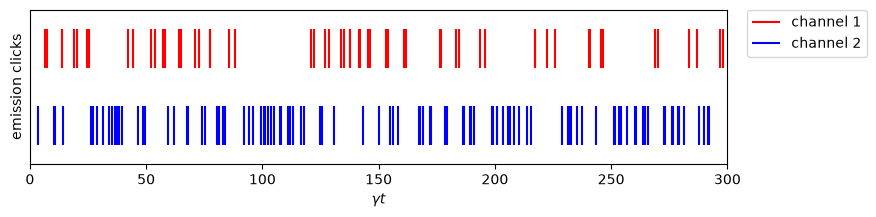

In [2]:
# ---------- spike train ----------
plt.figure(figsize=(9, 2))

# emissions: detector clicks
plt.vlines(t_emission_1 * gamma0, 0.5,  1.5, color="r", label="channel 1")
plt.vlines(t_emission_2 * gamma0, -0.5, -1.5, color="b", label="channel 2")
plt.ylabel("emission clicks")
plt.xlabel(r"$\gamma t$")
plt.xlim([0,300])
plt.ylim(-2, 2)
plt.yticks([])
plt.legend(bbox_to_anchor=(1.20, 1), borderaxespad=0)
plt.show()


In [3]:
def waiting_time(spikes):
    wtime = np.array([])
    for i in range(len(spikes)-1):
        wtime = np.append(wtime,spikes[i+1]-spikes[i])
        
    mean = sum(wtime)/len(wtime)
    dev = np.sqrt(sum(wtime**2)/len(wtime) - mean**2)

    print("mean waiting time  = ",mean)
    print("standard deviation = ",dev)

    if dev < 0.95*mean:
        print("likely sub-poissonian")
    elif dev > 1.05*mean:
        print("likely super-poissonian")
    else:
        print("likely poissonian")
        
    return wtime

print("**channel 1**")
wtime_1 = waiting_time(t_emission_1)

print("\n**channel 2**")
wtime_2 = waiting_time(t_emission_2)

**channel 1**
mean waiting time  =  61.70481027384709
standard deviation =  88.81537747083941
likely super-poissonian

**channel 2**
mean waiting time  =  24.947665561962545
standard deviation =  24.938660098004895
likely poissonian


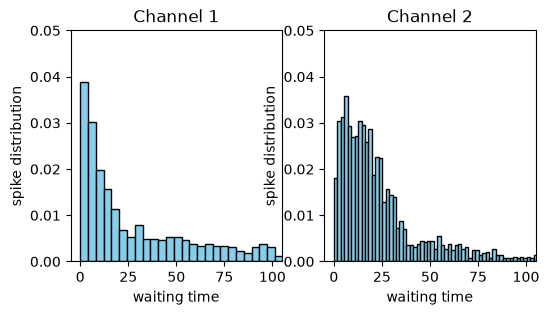

In [4]:
plt.figure(figsize=(6, 3.0))

plt.subplot(1,2,1)
plt.hist(wtime_1, density=True, bins=160, color='skyblue', edgecolor='black')
plt.xlim([-5,105])
plt.ylim([0,0.05])
plt.title("Channel 1")
plt.xlabel("waiting time")
plt.ylabel("spike distribution")

plt.subplot(1,2,2)
plt.hist(wtime_2, density=True, bins=100, color='skyblue', edgecolor='black')
plt.xlim([-5,105])
plt.ylim([0,0.05])
plt.title("Channel 2")
plt.xlabel("waiting time")
plt.ylabel("spike distribution")
plt.show()

### Second-order coherence function

The following code computes and plots $g^{(2)}(\tau)$ for emission. Corresponding to the waiting time distributions, it is clear that channel 1 is showing bunching and channel 2 antibunching.

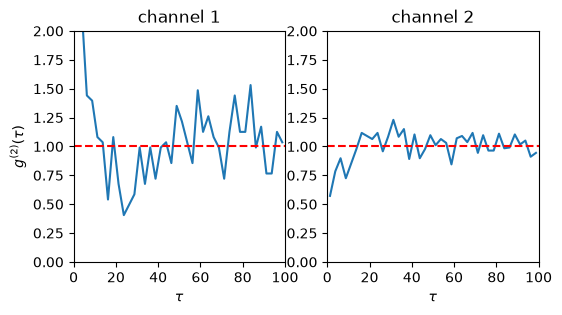

In [5]:
tau_max = 100  # max correlation time
dN = 100

def pair_times(spikes):

    time_gap = np.array([])
    i=1

    N_spikes = len(spikes)

    
    while i < N_spikes-dN:
        t0 = spikes[i]
        j = i+1
        while  (j < N_spikes) :
            t1 = spikes[j]
            if t1-t0 <= tau_max:
                time_gap = np.append(time_gap,t1-t0)
                j += 1
            else:
                break
        i += 1
        
    return time_gap

plt.figure(figsize=(6, 3.0))

plt.subplot(1,2,1)
tgap_1 = pair_times(t_emission_1)

nbins = 40
dtau = tau_max/nbins

N_spikes=len(t_emission_1)
norm = (N_spikes-dN)*N_spikes /t_emission_1[N_spikes-1] * dtau 
counts, bin = np.histogram(tgap_1, bins=nbins)
n=len(bin)
x1 = (bin[0:n-1]+bin[1:n])/2
y1 = counts/norm
plt.title("channel 1")
plt.ylim([0,2])
plt.plot(x1,y1)
plt.xlim([0,tau_max])
plt.xlabel(r"$\tau$")
plt.ylabel(r"$g^{(2)}(\tau)$")
plt.axhline(y=1, color='r', linestyle='--')

plt.subplot(1,2,2)
tgap_1 = pair_times(t_emission_2)

nbins = 40
dtau = tau_max/nbins

N_spikes=len(t_emission_2)
norm = (N_spikes-dN)*N_spikes /t_emission_2[N_spikes-1] * dtau 
counts, bin = np.histogram(tgap_1, bins=nbins)
n=len(bin)
x1 = (bin[0:n-1]+bin[1:n])/2
y1 = counts/norm
plt.title("channel 2")
plt.ylim([0,2])
plt.plot(x1,y1)
plt.xlim([0,tau_max])
plt.xlabel(r"$\tau$")
plt.axhline(y=1, color='r', linestyle='--')
plt.show()

## Single detector



In [6]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import *

# basis operators
i2 = qeye(2)
sz = [tensor(sigmaz(),i2),tensor(i2,sigmaz())]
sp = [tensor(sigmap(),i2),tensor(i2,sigmap())]
sm = [tensor(sigmam(),i2),tensor(i2,sigmam())]

# system parameters
gamma0=0.1
Omega = 0.8*gamma0
Delta=0

# position parameter
phi=np.pi/3
ep = np.exp(1j*phi)
em = np.exp(-1j*phi)

# qme
H = 0.5*Delta*(sz[0]+sz[1]) + 0.5*Omega*(ep*sp[0]+em*sm[0]+em*sp[1]+ep*sm[1])

# reset random number
rng = np.random.default_rng()

# we measure jump count of system 1, 2 and total

phi = 0
theta1 = np.pi/3
theta2 = np.pi/2
chi1= theta1 - 2*phi
chi2= theta2 - 2*phi
J1=np.exp(1j*chi1)*sm[0] + np.exp(-1j*chi1)*sm[1]
J2=np.exp(1j*chi2)*sm[0] + np.exp(-1j*chi2)*sm[1]

c_ops = [np.sqrt(gamma0)*J1,np.sqrt(gamma0)*J2]

# initially in the ground state
psi0 = tensor(basis(2,1),basis(2,1))

# execution time (trying to get 1000 photons)
tmax = 4000 / gamma0
# number of time sampling points
tsample = 8000
times = np.linspace(0, tmax, tsample)

# options for mcsolver
opts={"store_states": True,"keep_runs_results": True, "progress_bar": False}

# get a trajectory
result = mcsolve(H,psi0,times,c_ops,e_ops=[],ntraj=1,options=opts)

# get results
t_jump = np.array(result.col_times[0]) # time of all jumps
ch_jump = np.array(result.col_which[0]) # channel of all jumps

t_emission_1 = t_jump[ch_jump==0]
t_emission_2 = t_jump[ch_jump==1]

# is there enough counts?
# is there enough counts?
print("Number of emissions in channel 1 =", len(t_emission_1))
print("Number of emissions in channel 2 =", len(t_emission_2))

Number of emissions in channel 1 = 500
Number of emissions in channel 2 = 861


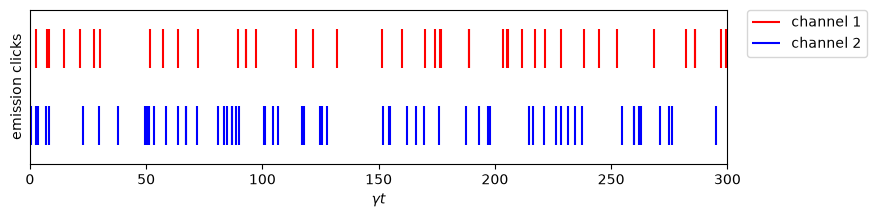

In [7]:
# ---------- spike train ----------
plt.figure(figsize=(9, 2))

# emissions: detector clicks
plt.vlines(t_emission_1 * gamma0, 0.5,  1.5, color="r", label="channel 1")
plt.vlines(t_emission_2 * gamma0, -0.5, -1.5, color="b", label="channel 2")
plt.ylabel("emission clicks")
plt.xlabel(r"$\gamma t$")
plt.xlim([0,300])
plt.ylim(-2, 2)
plt.yticks([])
plt.legend(bbox_to_anchor=(1.20, 1), borderaxespad=0)
plt.show()


In [8]:
def waiting_time(spikes):
    wtime = np.array([])
    for i in range(len(spikes)-1):
        wtime = np.append(wtime,spikes[i+1]-spikes[i])
        
    mean = sum(wtime)/len(wtime)
    dev = np.sqrt(sum(wtime**2)/len(wtime) - mean**2)

    print("mean waiting time  = ",mean)
    print("standard deviation = ",dev)

    if dev < 0.95*mean:
        print("likely sub-poissonian")
    elif dev > 1.05*mean:
        print("likely super-poissonian")
    else:
        print("likely poissonian")
        
    return wtime

print("**channel 1**")
wtime_1 = waiting_time(t_emission_1)

print("\n**channel 2**")
wtime_2 = waiting_time(t_emission_2)

**channel 1**
mean waiting time  =  80.04666362466227
standard deviation =  85.2873031278574
likely super-poissonian

**channel 2**
mean waiting time  =  46.408606437816715
standard deviation =  55.42331415457537
likely super-poissonian


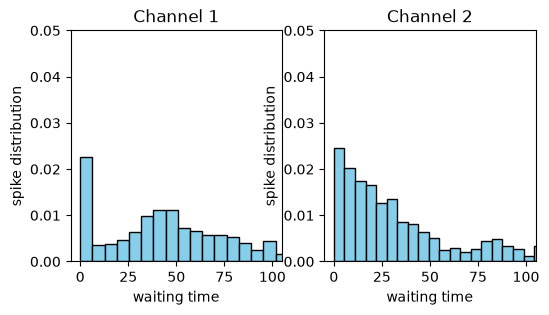

In [9]:
plt.figure(figsize=(6, 3.0))

plt.subplot(1,2,1)
plt.hist(wtime_1, density=True, bins=160, color='skyblue', edgecolor='black')
plt.xlim([-5,105])
plt.ylim([0,0.05])
plt.title("Channel 1")
plt.xlabel("waiting time")
plt.ylabel("spike distribution")

plt.subplot(1,2,2)
plt.hist(wtime_2, density=True, bins=100, color='skyblue', edgecolor='black')
plt.xlim([-5,105])
plt.ylim([0,0.05])
plt.title("Channel 2")
plt.xlabel("waiting time")
plt.ylabel("spike distribution")
plt.show()